In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# --- Ваш исходный код ---
FILEPATH = 'building_materials_transactions.csv'
DATETIME_COL = 'date'
VALUE_COL = 'revenue'
CAT_COL = 'region'

def load_data(filepath):
    return pd.read_csv(filepath)

def preprocess_data(df, datetime_col=None, value_col=None):
    if datetime_col and datetime_col in df.columns:
        df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
        df = df.sort_values(datetime_col).reset_index(drop=True)
    if value_col and value_col in df.columns:
        df = df.dropna(subset=[value_col]).reset_index(drop=True)
    return df

df = load_data(FILEPATH)
df = preprocess_data(df, DATETIME_COL, VALUE_COL)

df_ts = df.groupby(DATETIME_COL)[VALUE_COL].sum().reset_index()
df_ts = df_ts.sort_values(DATETIME_COL).reset_index(drop=True)

if len(df_ts) < 100:
    print(f"Внимание: длина ряда {len(df_ts)}. Для корректной работы требуется ≥100 значений.")
else:
    print(f"Длина временного ряда: {len(df_ts)} значений.")

y_full = df_ts[VALUE_COL].values
dates = df_ts[DATETIME_COL].values

print(f"Диапазон дат: {dates[0]} до {dates[-1]}")

Длина временного ряда: 313 значений.
Диапазон дат: 2019-01-07T00:00:00.000000 до 2024-12-30T00:00:00.000000


In [50]:
# 1. Разбиение на тренировочную (80%) и тестовую (20%) выборки
split_idx = int(len(y_full) * 0.8)
y_train = y_full[:split_idx]
y_test = y_full[split_idx:]
dates_train = dates[:split_idx]
dates_test = dates[split_idx:]

print(f"Размер train: {len(y_train)}, test: {len(y_test)}")

#ARIMA
try:
    arima_model = ARIMA(y_train, order=(1, 1, 1))
    arima_fitted = arima_model.fit()
    pred_arima = arima_fitted.forecast(steps=len(y_test))
except Exception as e:
    print(f"Ошибка ARIMA: {e}")
    pred_arima = np.full(len(y_test), np.mean(y_train))

#KNN
lags = 3
df_knn = pd.DataFrame({'y': y_full})
for i in range(1, lags + 1):
    df_knn[f'lag_{i}'] = df_knn['y'].shift(i)

X_knn_full = df_knn.drop('y', axis=1).values
y_knn_full = df_knn['y'].values

# Обучаем на данных от индекса lags до split_idx
X_train_knn = X_knn_full[lags:split_idx]
y_train_knn = y_knn_full[lags:split_idx]

# Тестируем на данных от split_idx до конца (длина в точности равна len(y_test)!)
X_test_knn = X_knn_full[split_idx:]
y_test_knn = y_knn_full[split_idx:] 

# Масштабирование
scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_knn_scaled, y_train_knn)
pred_knn = knn_model.predict(X_test_knn_scaled)

print(f"Проверка длин: y_test = {len(y_test)}, pred_knn = {len(pred_knn)}")

Размер train: 250, test: 63
Проверка длин: y_test = 63, pred_knn = 63


In [ ]:
# x - это временной индекс (0, 1, 2, ...)
x_1param = np.arange(len(y_full)).reshape(-1, 1)
x_train_1, x_test_1 = x_1param[:split_idx], x_1param[split_idx:]

# --- МНК (Linear Regression) ---
mnk_model = LinearRegression()
mnk_model.fit(x_train_1, y_train)
pred_mnk = mnk_model.predict(x_test_1)


# --- SVM (SVR) ---
# Масштабирование обязательно для SVR
scaler_svr = StandardScaler()
x_train_1_scaled = scaler_svr.fit_transform(x_train_1)
x_test_1_scaled = scaler_svr.transform(x_test_1)

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(x_train_1_scaled, y_train)
pred_svr = svr_model.predict(x_test_1_scaled)

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---------- Датафрейм с двумя признаками ----------
df_reg2 = pd.DataFrame({
    'y': y_full,
    'x1': pd.Series(y_full).shift(1), 
}).dropna().reset_index(drop=True)

split_idx_2 = int(len(df_reg2) * 0.8)
train_2 = df_reg2.iloc[:split_idx_2]
test_2 = df_reg2.iloc[split_idx_2:]

X_train_2 = train_2[['x1']].values
y_train_2 = train_2['y'].values
X_test_2 = test_2[['x1']].values
y_test_2 = test_2['y'].values


# ---------- МНК ----------
mnk2_model = LinearRegression()
mnk2_model.fit(X_train_2, y_train_2)
pred_mnk2 = mnk2_model.predict(X_test_2)

def moving_average_forecast(y, window):
    preds = []
    for i in range(len(y)):
        start = max(0, i - window)
        preds.append(np.mean(y[start:i]) if i > 0 else y[0])
    return np.array(preds)


# прогноз на тестовой части, обучаясь на всём ряду до текущей точки
# (walk-forward: модель видит только прошлое, не будущее)
window = 5  # окно, можно 3, 7, 10, 12 — подберите под период синусоиды
ma_forecast = np.full(len(y_test), np.nan)

for i in range(len(y_test)):
    idx = split_idx + i
    history = y_full[max(0, idx - window):idx]
    ma_forecast[i] = history.mean()


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train_2)
X_test_s = scaler_X.transform(X_test_2)

y_train_s = scaler_y.fit_transform(y_train_2.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test_2.reshape(-1, 1)).ravel()

svr2_model = SVR(kernel='rbf', C=200.0, epsilon=0.2, gamma='scale')
svr2_model.fit(X_train_s, y_train_s)

pred_svr2_s = svr2_model.predict(X_test_s)
pred_svr2 = scaler_y.inverse_transform(pred_svr2_s.reshape(-1, 1)).ravel()

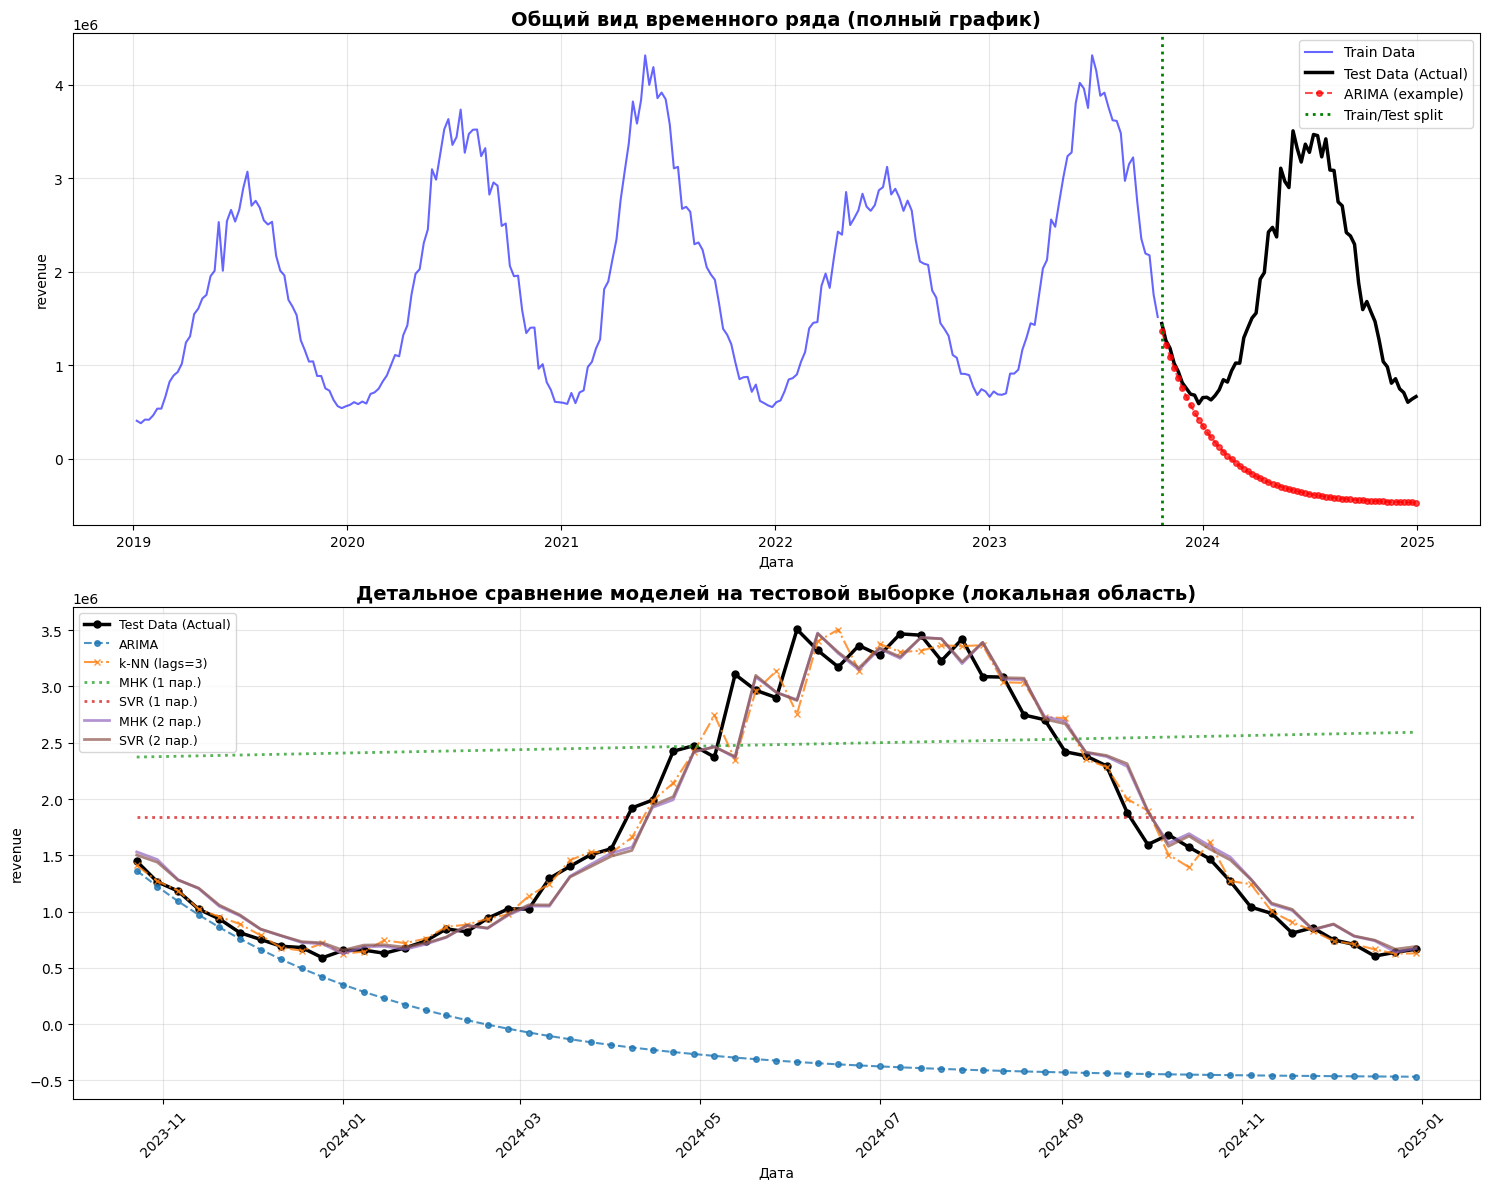


--- Статистика тестовой области ---
Диапазон дат: 2023-10-23T00:00:00.000000 — 2024-12-30T00:00:00.000000
Количество точек: 63
Минимальное значение: 589858.32
Максимальное значение: 3506625.95
Среднее значение: 1726350.21


In [52]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

ax1.plot(dates[:split_idx], y_train, label='Train Data', color='blue', alpha=0.6, linewidth=1.5)
ax1.plot(dates[split_idx:], y_test, label='Test Data (Actual)', color='black', linewidth=2.5)

ax1.plot(dates_test, pred_arima, label='ARIMA (example)', linestyle='--', marker='o', 
         color='red', alpha=0.7, markersize=4)

ax1.axvline(x=dates[split_idx], color='green', linestyle=':', linewidth=2, 
            label='Train/Test split')

ax1.set_title('Общий вид временного ряда (полный график)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel(VALUE_COL)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

ax2.plot(dates_test, y_test, label='Test Data (Actual)', color='black', linewidth=2.5, marker='o', markersize=5)

# Все предсказания на тестовой области
ax2.plot(dates_test, pred_arima, label='ARIMA', linestyle='--', marker='o', alpha=0.8, markersize=4)
ax2.plot(dates_test, pred_knn, label='k-NN (lags=3)', linestyle='-.', marker='x', alpha=0.8, markersize=4)
ax2.plot(dates_test, pred_mnk, label='МНК (1 пар.)', linestyle=':', alpha=0.8, linewidth=2)
ax2.plot(dates_test, pred_svr, label='SVR (1 пар.)', linestyle=':', alpha=0.8, linewidth=2)
ax2.plot(dates_test, pred_mnk2, label='МНК (2 пар.)', linestyle='-', alpha=0.7, linewidth=2)
ax2.plot(dates_test, pred_svr2, label='SVR (2 пар.)', linestyle='-', alpha=0.7, linewidth=2)

ax2.set_title('Детальное сравнение моделей на тестовой выборке (локальная область)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel(VALUE_COL)
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n--- Статистика тестовой области ---")
print(f"Диапазон дат: {dates_test[0]} — {dates_test[-1]}")
print(f"Количество точек: {len(y_test)}")
print(f"Минимальное значение: {y_test.min():.2f}")
print(f"Максимальное значение: {y_test.max():.2f}")
print(f"Среднее значение: {y_test.mean():.2f}")

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def model_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name}: MAE = {mae:,.2f} | RMSE = {rmse:,.2f} | R² = {r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


print('=== Метрики моделей на тестовой выборке ===')
m_arima = model_metrics(y_test, pred_arima,  'ARIMA (1,1,1)')
m_knn   = model_metrics(y_test_knn, pred_knn, 'k-NN (k=5, lags=3)')
m_mnk   = model_metrics(y_test, pred_mnk,   'МНК (1 параметр)')
m_svr   = model_metrics(y_test, pred_svr,   'SVR (1 параметр)')
metrics_mnk2 = model_metrics(y_test_2, pred_mnk2, 'МНК (2 пар.)')
metrics_svr2 = model_metrics(y_test_2, pred_svr2, 'SVR (2 пар.)')

m_ma = model_metrics(y_test, ma_forecast, f'Скользящее среднее (k={window})')

=== Метрики моделей на тестовой выборке ===
ARIMA (1,1,1): MAE = 1,826,831.55 | RMSE = 2,224,135.29 | R² = -4.0291
k-NN (k=5, lags=3): MAE = 116,134.31 | RMSE = 190,970.75 | R² = 0.9629
МНК (1 параметр): MAE = 1,098,649.03 | RMSE = 1,237,379.48 | R² = -0.5566
SVR (1 параметр): MAE = 906,056.38 | RMSE = 998,134.06 | R² = -0.0129
МНК (2 пар.): MAE = 142,905.11 | RMSE = 200,014.65 | R² = 0.9593
SVR (2 пар.): MAE = 142,870.73 | RMSE = 199,613.86 | R² = 0.9595
Скользящее среднее (k=5): MAE = 321,199.79 | RMSE = 379,465.02 | R² = 0.8536


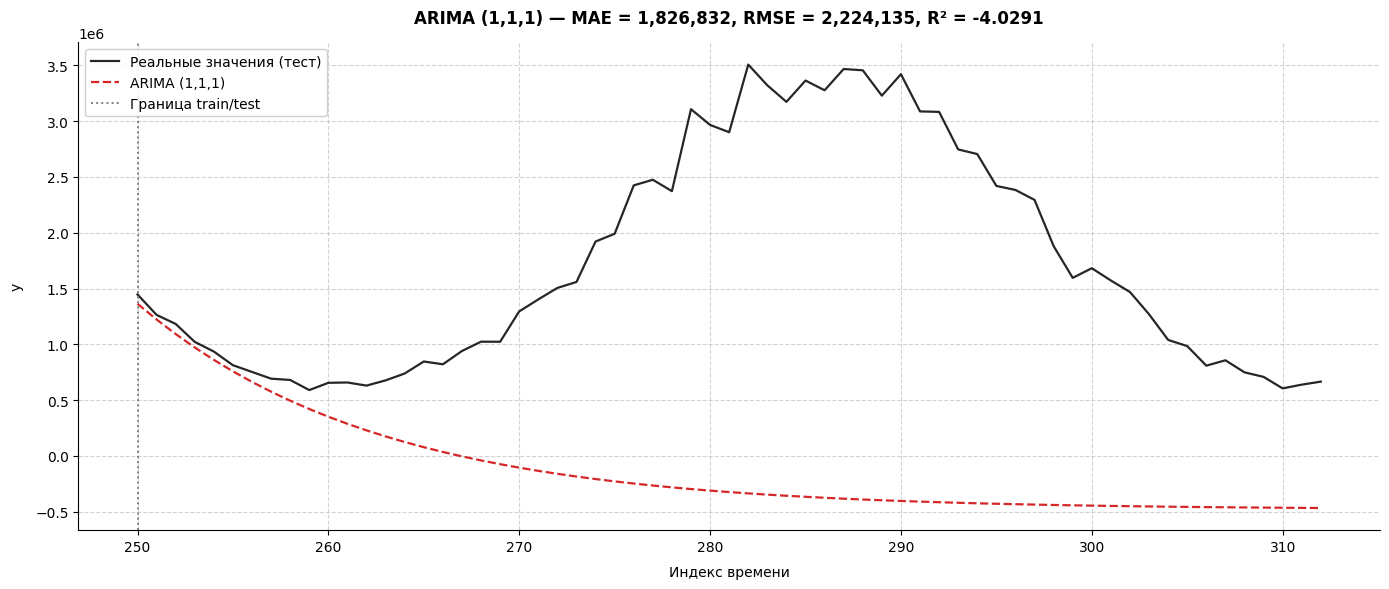

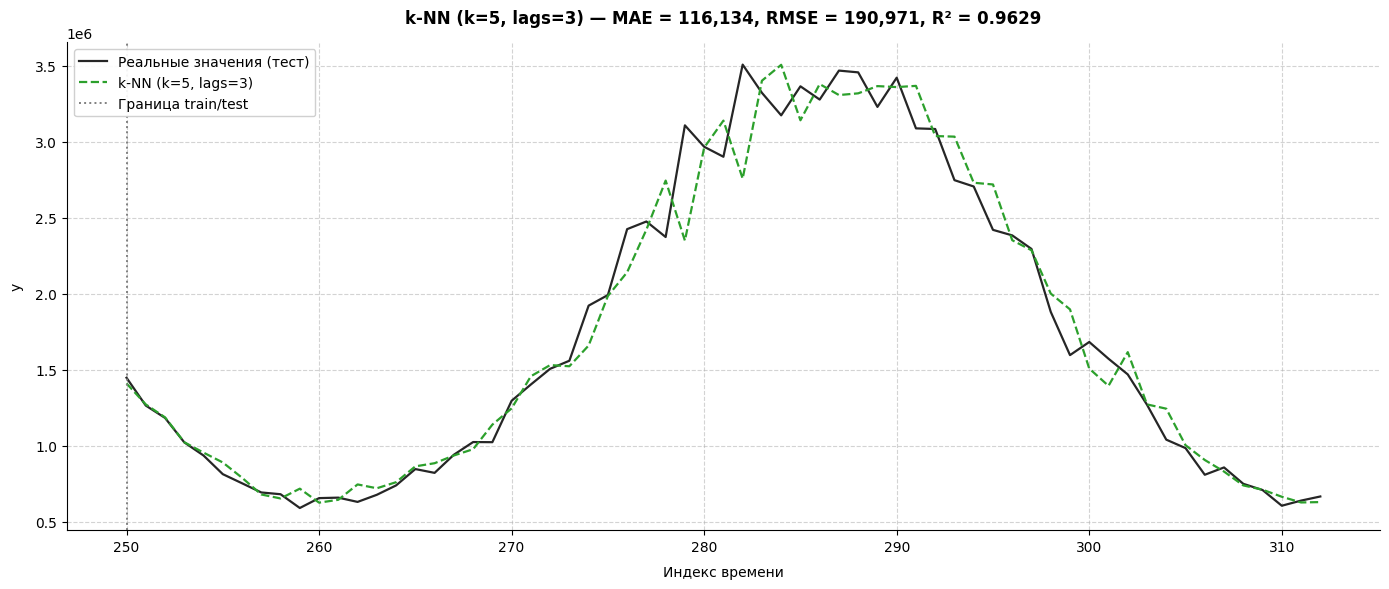

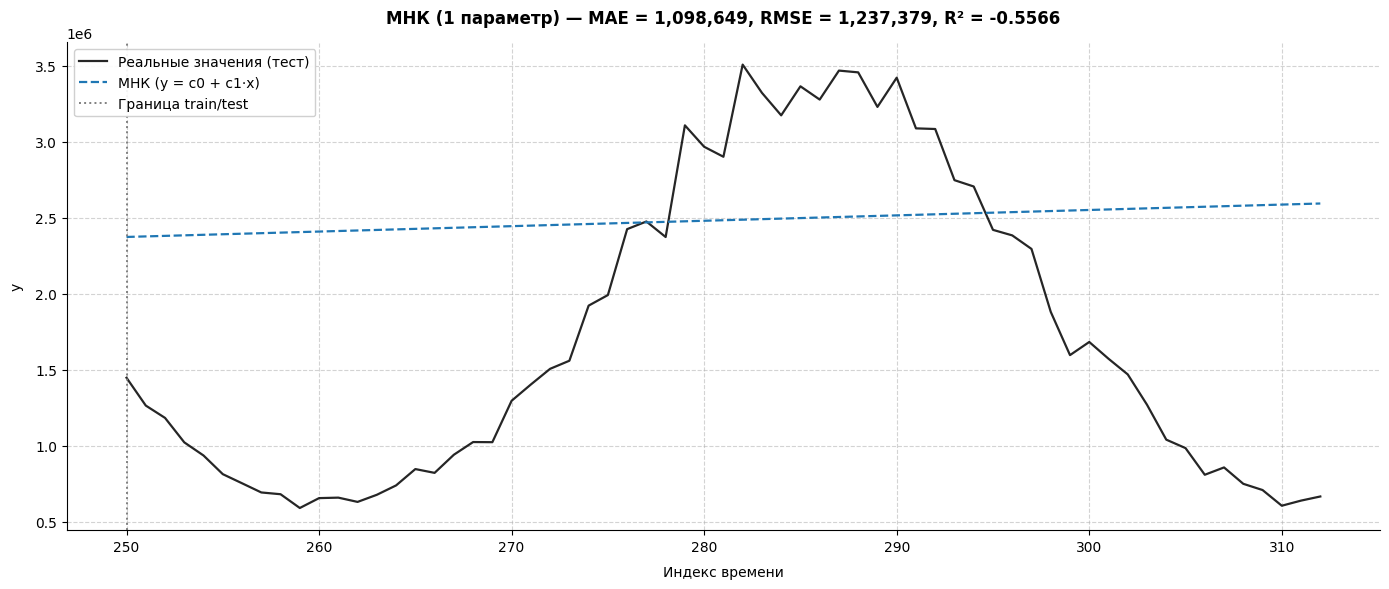

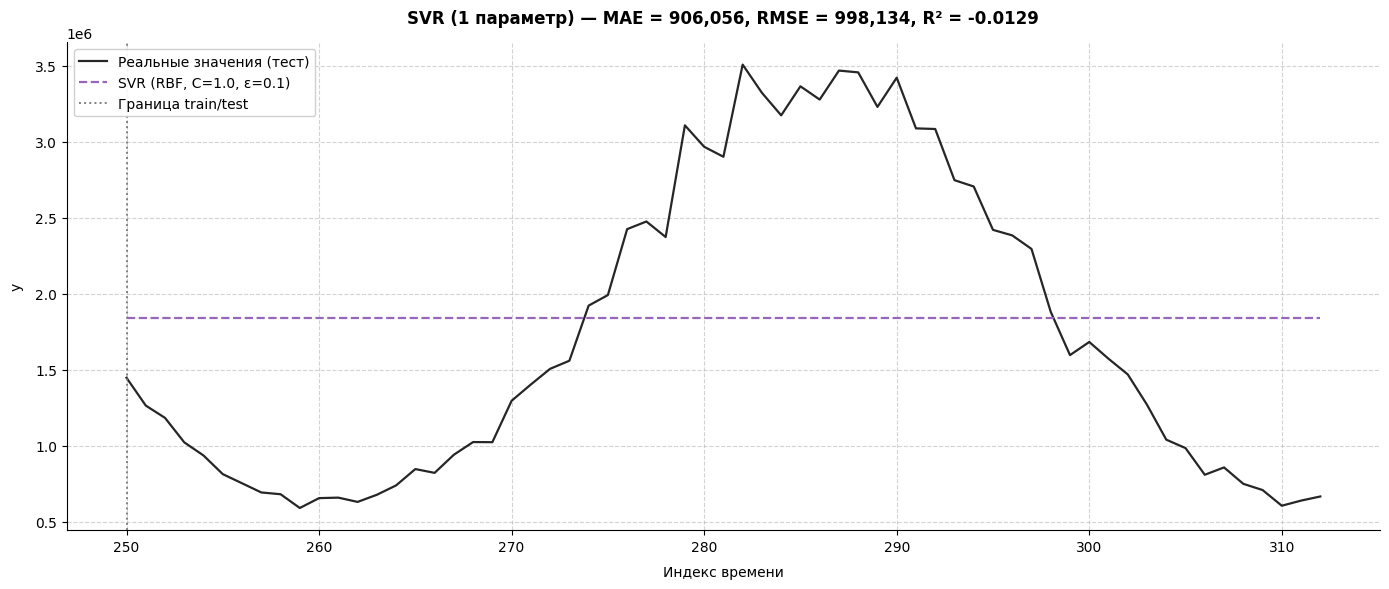

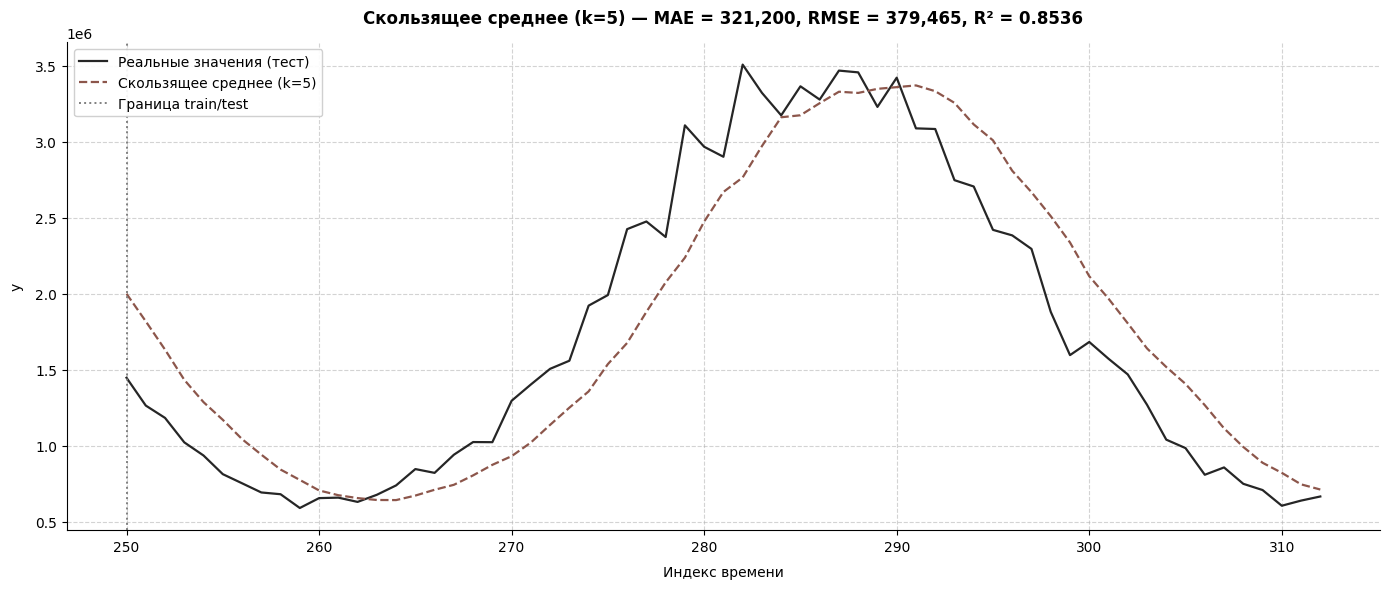

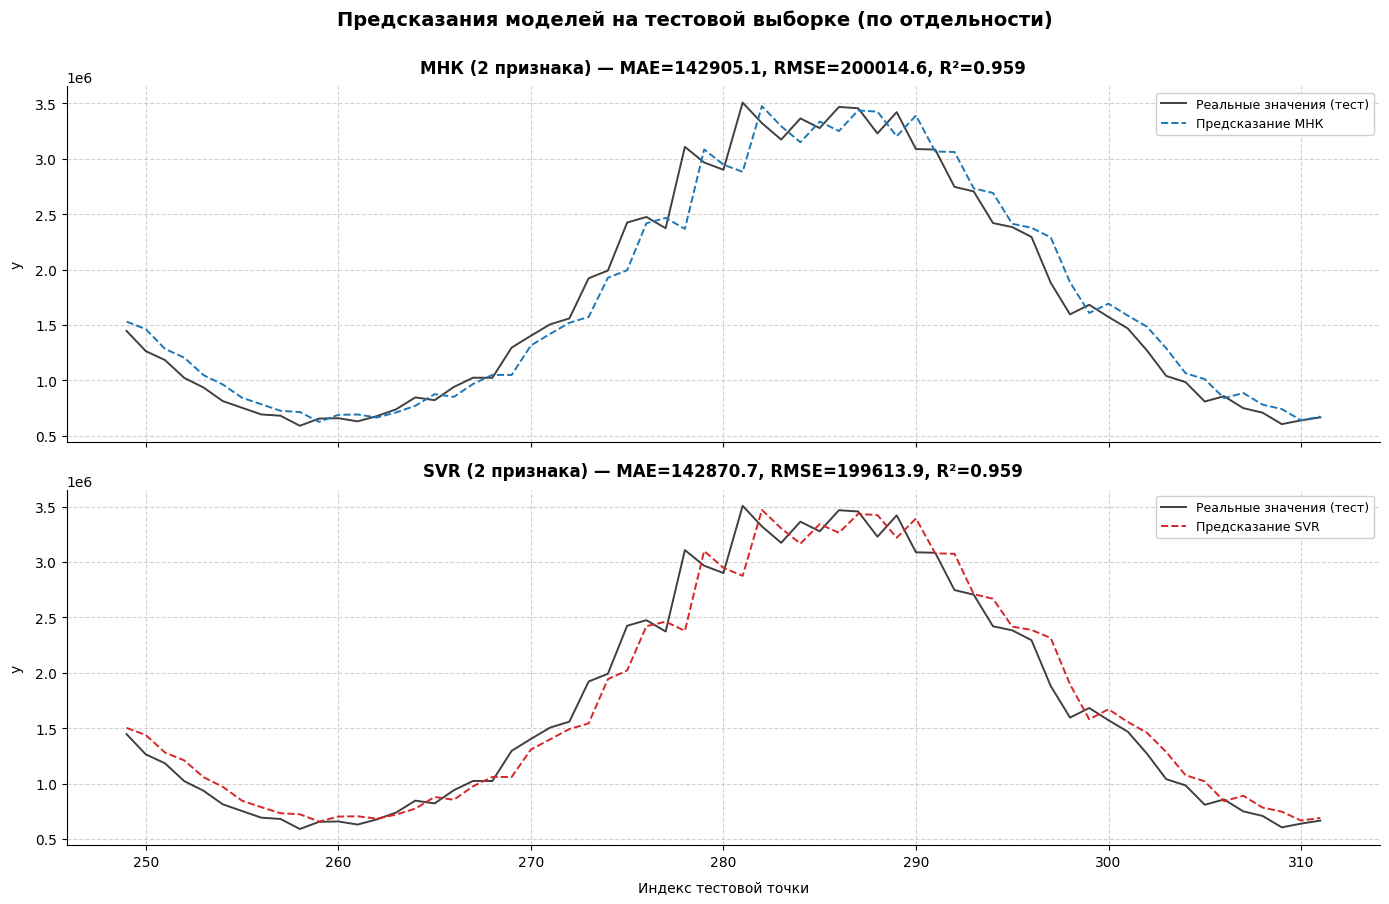

In [61]:
fig, ax = plt.subplots(figsize=(14, 6))
x_test_idx = np.arange(split_idx, len(y_full))

ax.plot(x_test_idx, y_test, color='black', linewidth=1.6,
        alpha=0.85, label='Реальные значения (тест)')
ax.plot(x_test_idx, pred_arima, color='#d62728', linewidth=1.6,
        linestyle='--', label='ARIMA (1,1,1)')

ax.axvline(split_idx, color='gray', linestyle=':', linewidth=1.4,
           label='Граница train/test')
ax.set_xlabel('Индекс времени', labelpad=8)
ax.set_ylabel('y', labelpad=8)
ax.set_title(
    f'ARIMA (1,1,1) — MAE = {m_arima["MAE"]:,.0f}, '
    f'RMSE = {m_arima["RMSE"]:,.0f}, R² = {m_arima["R2"]:.4f}',
    pad=14, fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x_test_idx, y_test, color='black', linewidth=1.6,
        alpha=0.85, label='Реальные значения (тест)')
ax.plot(x_test_idx, pred_knn, color='#2ca02c', linewidth=1.6,
        linestyle='--', label='k-NN (k=5, lags=3)')

ax.axvline(split_idx, color='gray', linestyle=':', linewidth=1.4,
           label='Граница train/test')
ax.set_xlabel('Индекс времени', labelpad=8)
ax.set_ylabel('y', labelpad=8)
ax.set_title(
    f'k-NN (k=5, lags=3) — MAE = {m_knn["MAE"]:,.0f}, '
    f'RMSE = {m_knn["RMSE"]:,.0f}, R² = {m_knn["R2"]:.4f}',
    pad=14, fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x_test_idx, y_test, color='black', linewidth=1.6,
        alpha=0.85, label='Реальные значения (тест)')
ax.plot(x_test_idx, pred_mnk, color='#1f77b4', linewidth=1.6,
        linestyle='--', label='МНК (y = c0 + c1·x)')

ax.axvline(split_idx, color='gray', linestyle=':', linewidth=1.4,
           label='Граница train/test')
ax.set_xlabel('Индекс времени', labelpad=8)
ax.set_ylabel('y', labelpad=8)
ax.set_title(
    f'МНК (1 параметр) — MAE = {m_mnk["MAE"]:,.0f}, '
    f'RMSE = {m_mnk["RMSE"]:,.0f}, R² = {m_mnk["R2"]:.4f}',
    pad=14, fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x_test_idx, y_test, color='black', linewidth=1.6,
        alpha=0.85, label='Реальные значения (тест)')
ax.plot(x_test_idx, pred_svr, color='#9467bd', linewidth=1.6,
        linestyle='--', label='SVR (RBF, C=1.0, ε=0.1)')

ax.axvline(split_idx, color='gray', linestyle=':', linewidth=1.4,
           label='Граница train/test')
ax.set_xlabel('Индекс времени', labelpad=8)
ax.set_ylabel('y', labelpad=8)
ax.set_title(
    f'SVR (1 параметр) — MAE = {m_svr["MAE"]:,.0f}, '
    f'RMSE = {m_svr["RMSE"]:,.0f}, R² = {m_svr["R2"]:.4f}',
    pad=14, fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x_test_idx, y_test, color='black', linewidth=1.6,
        alpha=0.85, label='Реальные значения (тест)')
ax.plot(x_test_idx, ma_forecast, color='#8c564b', linewidth=1.6,
        linestyle='--', label=f'Скользящее среднее (k={window})')

ax.axvline(split_idx, color='gray', linestyle=':', linewidth=1.4,
           label='Граница train/test')
ax.set_xlabel('Индекс времени', labelpad=8)
ax.set_ylabel('y', labelpad=8)
ax.set_title(
    f'Скользящее среднее (k={window}) — MAE = {m_ma["MAE"]:,.0f}, '
    f'RMSE = {m_ma["RMSE"]:,.0f}, R² = {m_ma["R2"]:.4f}',
    pad=14, fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()


x_test_idx = test_2.index.to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- МНК ---
axes[0].plot(x_test_idx, y_test_2, color='black', linewidth=1.4,
             alpha=0.75, label='Реальные значения (тест)')
axes[0].plot(x_test_idx, pred_mnk2, color='#1f77b4', linewidth=1.4,
             linestyle='--', label='Предсказание МНК')
axes[0].set_ylabel('y', labelpad=8)
axes[0].set_title(
    f'МНК (2 признака) — MAE={metrics_mnk2["MAE"]:.1f}, '
    f'RMSE={metrics_mnk2["RMSE"]:.1f}, R²={metrics_mnk2["R2"]:.3f}',
    pad=10, fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.55)
axes[0].set_axisbelow(True)
axes[0].legend(loc='upper right', fontsize=9, framealpha=0.92)
sns.despine(ax=axes[0], top=True, right=True)

# --- SVR ---
axes[1].plot(x_test_idx, y_test_2, color='black', linewidth=1.4,
             alpha=0.75, label='Реальные значения (тест)')
axes[1].plot(x_test_idx, pred_svr2, color='#d62728', linewidth=1.4,
             linestyle='--', label='Предсказание SVR')
axes[1].set_xlabel('Индекс тестовой точки', labelpad=8)
axes[1].set_ylabel('y', labelpad=8)
axes[1].set_title(
    f'SVR (2 признака) — MAE={metrics_svr2["MAE"]:.1f}, '
    f'RMSE={metrics_svr2["RMSE"]:.1f}, R²={metrics_svr2["R2"]:.3f}',
    pad=10, fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.55)
axes[1].set_axisbelow(True)
axes[1].legend(loc='upper right', fontsize=9, framealpha=0.92)
sns.despine(ax=axes[1], top=True, right=True)

fig.suptitle('Предсказания моделей на тестовой выборке (по отдельности)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [62]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ---------- Признаки: 5 лагов ----------
df_lasso = pd.DataFrame({'y': y_full})
for lag in range(1, 6):
    df_lasso[f'lag_{lag}'] = df_lasso['y'].shift(lag)

df_lasso = df_lasso.dropna().reset_index(drop=True)

feature_cols = [c for c in df_lasso.columns if c != 'y']
print(f'Признаки: {feature_cols}')
print(f'Размер: {len(df_lasso)}')


# ---------- Разбиение 80/20 ----------
split_idx_lasso = int(len(df_lasso) * 0.8)
train = df_lasso.iloc[:split_idx_lasso]
test = df_lasso.iloc[split_idx_lasso:]

X_train = train[feature_cols].values
y_train = train['y'].values
X_test = test[feature_cols].values
y_test = test['y'].values


# ---------- Масштабирование ----------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


# ---------- Lasso ----------
lasso_model = Lasso(alpha=1000.0, max_iter=50000, random_state=42)
lasso_model.fit(X_train_s, y_train)
pred_lasso = lasso_model.predict(X_test_s)


# ---------- Метрики ----------
mae = mean_absolute_error(y_test, pred_lasso)
rmse = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2 = r2_score(y_test, pred_lasso)

print(f'\nLasso (α={lasso_model.alpha}):')
print(f'  MAE  = {mae:,.0f}')
print(f'  RMSE = {rmse:,.0f}')
print(f'  R²   = {r2:.4f}')
print(f'  Ненулевых коэффициентов: {int(np.sum(lasso_model.coef_ != 0))} из {len(feature_cols)}')

coef_df = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': lasso_model.coef_,
})
print('\nКоэффициенты:')
print(coef_df.to_string(index=False))

Признаки: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']
Размер: 308

Lasso (α=1000.0):
  MAE  = 115,242
  RMSE = 158,081
  R²   = 0.9750
  Ненулевых коэффициентов: 5 из 5

Коэффициенты:
Признак    Коэффициент
  lag_1  788137.541139
  lag_2  404583.024215
  lag_3  263860.237443
  lag_4   -1111.650975
  lag_5 -460710.462651


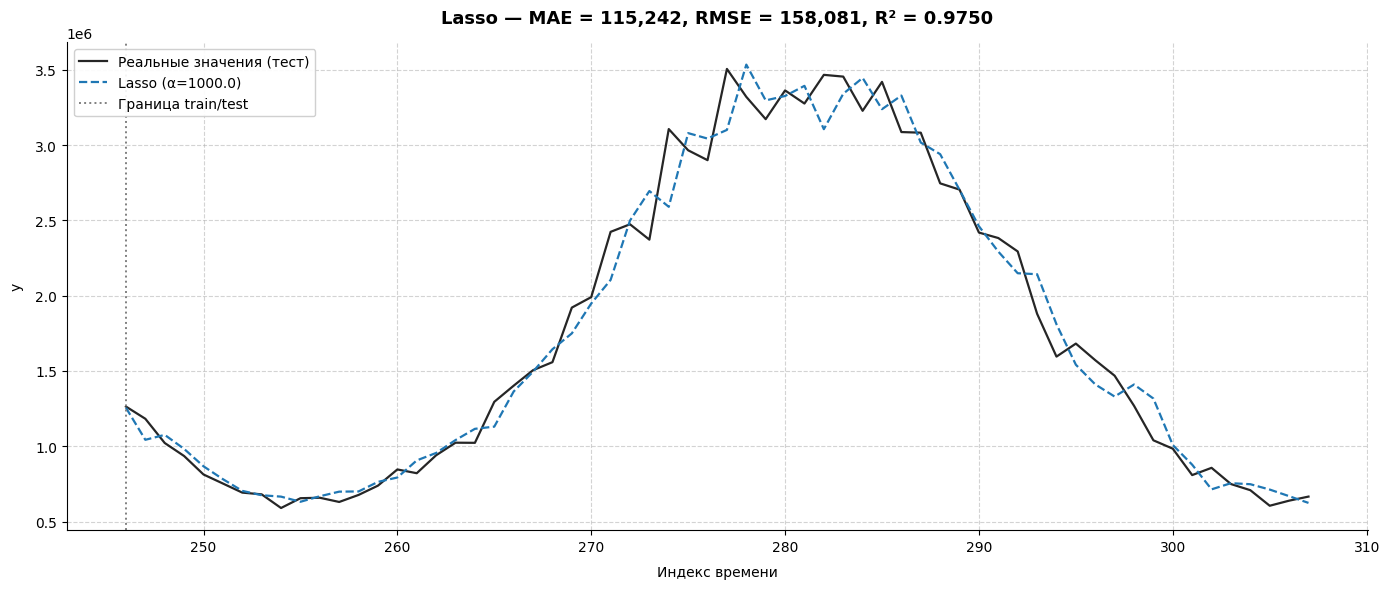

In [63]:
x_test_idx = np.arange(split_idx_lasso, split_idx_lasso + len(y_test))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_test_idx, y_test, color='black', linewidth=1.6,
        alpha=0.85, label='Реальные значения (тест)')
ax.plot(x_test_idx, pred_lasso, color='#1f77b4', linewidth=1.6,
        linestyle='--', label=f'Lasso (α={lasso_model.alpha})')
ax.axvline(split_idx_lasso, color='gray', linestyle=':', linewidth=1.4,
           label='Граница train/test')
ax.set_xlabel('Индекс времени', labelpad=8)
ax.set_ylabel('y', labelpad=8)
ax.set_title(f'Lasso — MAE = {mae:,.0f}, RMSE = {rmse:,.0f}, R² = {r2:.4f}',
             pad=14, fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.55)
ax.set_axisbelow(True)
ax.legend(loc='upper left', fontsize=10, framealpha=0.92)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()